In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
df = pd.read_csv("Synthetic_Financial_datasets_log.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 6,362,620 rows x 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [3]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Duplicates: {df.duplicated().sum()} ===")

=== Missing Values ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== Duplicates: 0 ===


In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


=== Class Imbalance ===
Non-Fraud:  6,354,407 (99.8709%)
Fraud:          8,213 (0.1291%)
Ratio:     1 Fraud : 773 Non-Fraud


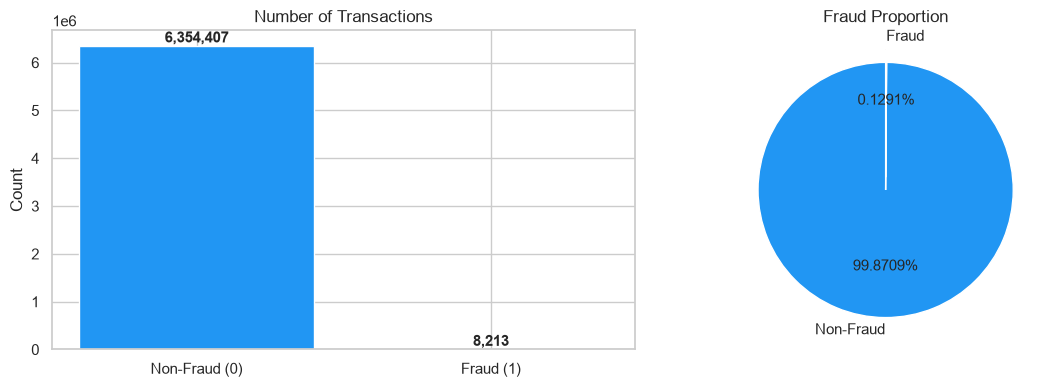

In [5]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100
print("=== Class Imbalance ===")
print(f"Non-Fraud: {fraud_counts[0]:>10,} ({fraud_pct[0]:.4f}%)")
print(f"Fraud:     {fraud_counts[1]:>10,} ({fraud_pct[1]:.4f}%)")
print(f"Ratio:     1 Fraud : {int(fraud_counts[0]/fraud_counts[1])} Non-Fraud")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Count plot
bars = axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], fraud_counts.values, 
                    color=['#2196F3', '#F44336'])
axes[0].set_title("Number of Transactions")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
# Pie chart
axes[1].pie(fraud_counts.values, labels=['Non-Fraud', 'Fraud'], 
            autopct='%1.4f%%', colors=['#2196F3', '#F44336'],
            explode=[0, 0.1], startangle=90)
axes[1].set_title("Fraud Proportion")
plt.tight_layout()
plt.show()

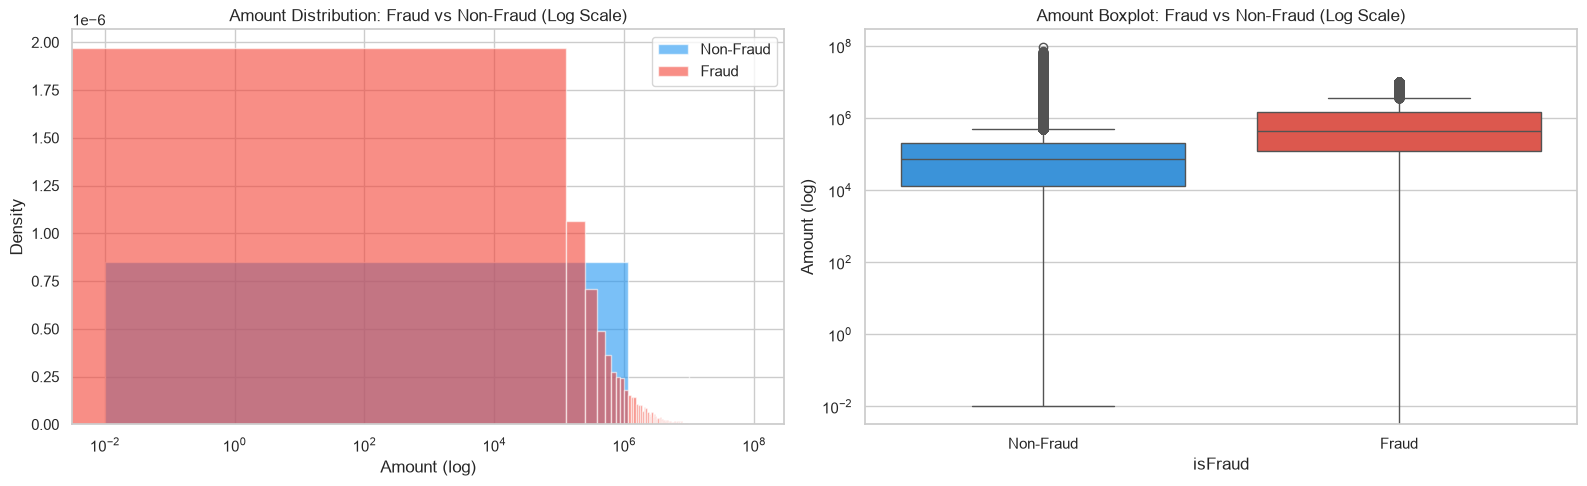

=== Amount Statistics ===
isFraud             0             1
count    6.354407e+06  8.213000e+03
mean     1.781970e+05  1.467967e+06
std      5.962370e+05  2.404253e+06
min      1.000000e-02  0.000000e+00
25%      1.336840e+04  1.270913e+05
50%      7.468472e+04  4.414234e+05
75%      2.083648e+05  1.517771e+06
max      9.244552e+07  1.000000e+07


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Histogram (log scale)
for label, color, name in [(0, '#2196F3', 'Non-Fraud'), (1, '#F44336', 'Fraud')]:
    subset = df[df['isFraud'] == label]['amount']
    axes[0].hist(subset, bins=80, alpha=0.6, color=color, label=name, density=True)
axes[0].set_xscale('log')
axes[0].set_title("Amount Distribution: Fraud vs Non-Fraud (Log Scale)")
axes[0].set_xlabel("Amount (log)")
axes[0].set_ylabel("Density")
axes[0].legend()
# Boxplot comparison
sns.boxplot(x='isFraud', y='amount', data=df, palette=['#2196F3', '#F44336'], ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[1].set_title("Amount Boxplot: Fraud vs Non-Fraud (Log Scale)")
axes[1].set_ylabel("Amount (log)")
plt.tight_layout()
plt.show()
# Key stats
print("=== Amount Statistics ===")
print(df.groupby('isFraud')['amount'].describe().T)

In [7]:
q1 = df['amount'].quantile(0.25)
q3 = df['amount'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outliers = df[df['amount'] > upper_bound]
outlier_fraud = outliers['isFraud'].sum()
print("=== Outlier Analysis (IQR Method) ===")
print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Upper Bound (Q3 + 1.5*IQR): {upper_bound:,.2f}")
print(f"Total Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Fraud in Outliers: {outlier_fraud:,} ({outlier_fraud/df['isFraud'].sum()*100:.2f}% of all fraud)")

=== Outlier Analysis (IQR Method) ===
Q1: 13,389.57
Q3: 208,721.48
IQR: 195,331.91
Upper Bound (Q3 + 1.5*IQR): 501,719.34
Total Outliers: 338,078 (5.31%)
Fraud in Outliers: 3,854 (46.93% of all fraud)


=== Fraud Rate by Transaction Type ===
    type   total  fraud_count  fraud_rate_%
TRANSFER  532909         4097        0.7688
CASH_OUT 2237500         4116        0.1840
 CASH_IN 1399284            0        0.0000
   DEBIT   41432            0        0.0000
 PAYMENT 2151495            0        0.0000


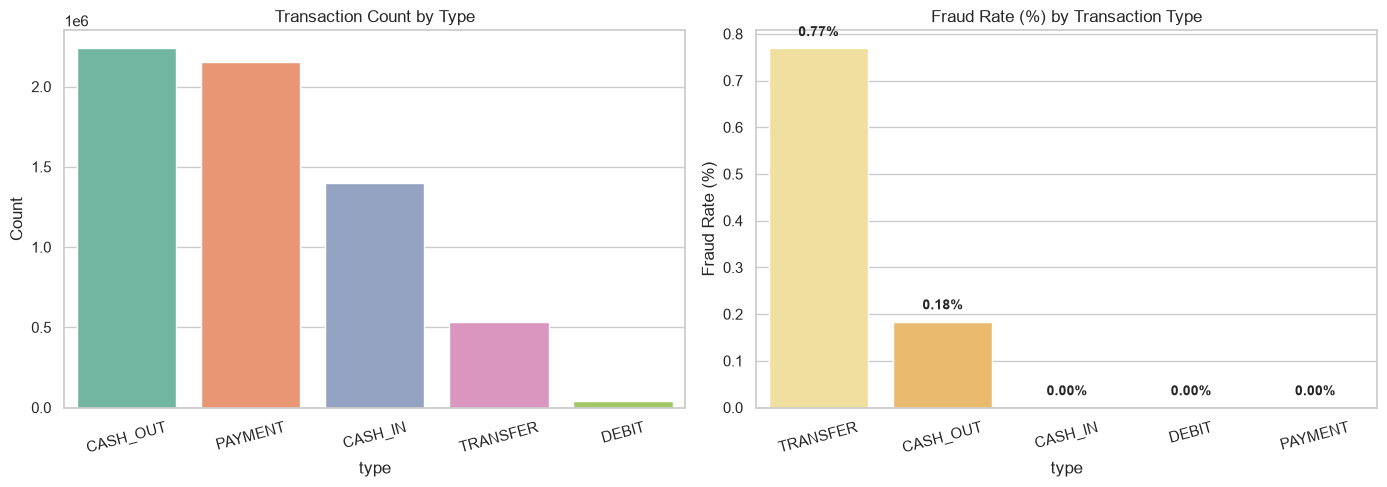

In [8]:
type_stats = df.groupby('type').agg(
    total=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum')
).reset_index()
type_stats['fraud_rate_%'] = (type_stats['fraud_count'] / type_stats['total'] * 100).round(4)
type_stats = type_stats.sort_values('fraud_rate_%', ascending=False)
print("=== Fraud Rate by Transaction Type ===")
print(type_stats.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Transaction count by type
sns.countplot(data=df, x='type', order=df['type'].value_counts().index, 
              palette='Set2', ax=axes[0])
axes[0].set_title("Transaction Count by Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=15)
# Fraud rate by type
sns.barplot(data=type_stats, x='type', y='fraud_rate_%', palette='YlOrRd', ax=axes[1])
axes[1].set_title("Fraud Rate (%) by Transaction Type")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].tick_params(axis='x', rotation=15)
for i, row in type_stats.reset_index(drop=True).iterrows():
    axes[1].text(i, row['fraud_rate_%'] + 0.02, f"{row['fraud_rate_%']:.2f}%", 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

=== Fraud Rate by Destination Channel ===
dest_channel   total  fraud_count  fraud_rate_%
Customer (C) 4211125         8213         0.195
Merchant (M) 2151495            0         0.000


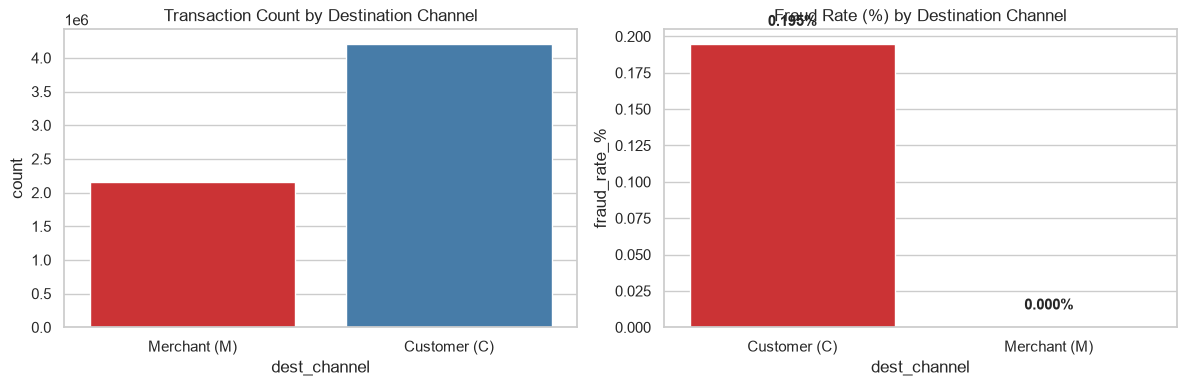

In [9]:
df['dest_channel'] = df['nameDest'].str[0].map({'C': 'Customer (C)', 'M': 'Merchant (M)'})
channel_stats = df.groupby('dest_channel').agg(
    total=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum')
).reset_index()
channel_stats['fraud_rate_%'] = (channel_stats['fraud_count'] / channel_stats['total'] * 100).round(4)
print("=== Fraud Rate by Destination Channel ===")
print(channel_stats.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='dest_channel', palette='Set1', ax=axes[0])
axes[0].set_title("Transaction Count by Destination Channel")
sns.barplot(data=channel_stats, x='dest_channel', y='fraud_rate_%', palette='Set1', ax=axes[1])
axes[1].set_title("Fraud Rate (%) by Destination Channel")
for i, row in channel_stats.reset_index(drop=True).iterrows():
    axes[1].text(i, row['fraud_rate_%'] + 0.01, f"{row['fraud_rate_%']:.3f}%", 
                 ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

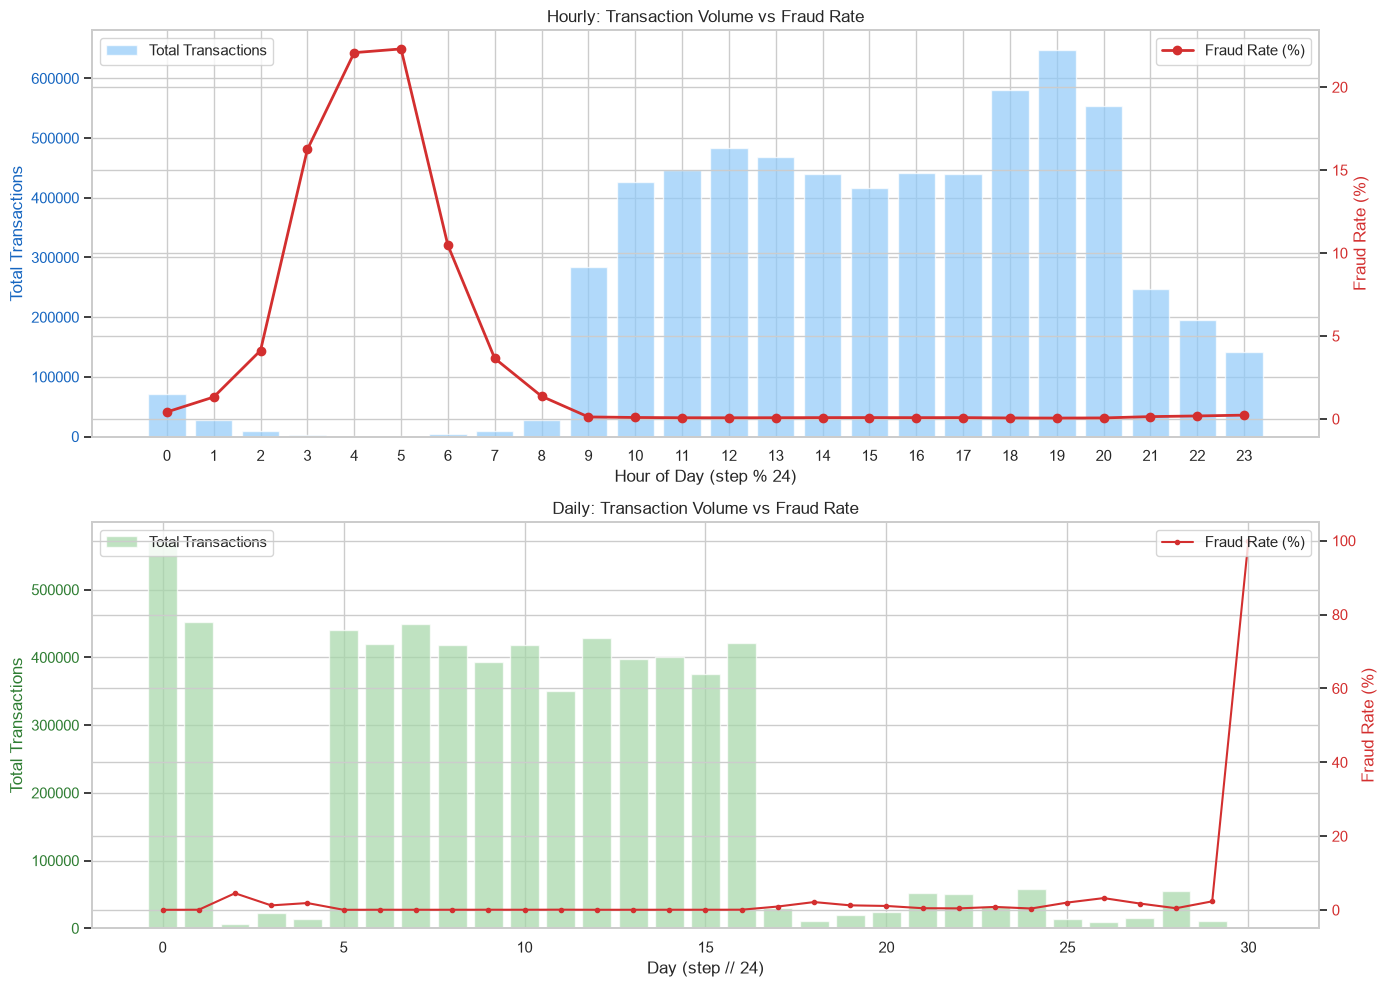

In [10]:
df['hour_of_day'] = df['step'] % 24
df['day'] = df['step'] // 24
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
# --- Hourly ---
hourly = df.groupby('hour_of_day').agg(
    total=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum')
).reset_index()
hourly['fraud_rate_%'] = hourly['fraud_count'] / hourly['total'] * 100
ax1 = axes[0]
ax1.bar(hourly['hour_of_day'], hourly['total'], color='#90CAF9', alpha=0.7, label='Total Transactions')
ax1.set_xlabel('Hour of Day (step % 24)')
ax1.set_ylabel('Total Transactions', color='#1565C0')
ax1.set_xticks(range(24))
ax1.tick_params(axis='y', labelcolor='#1565C0')
ax1b = ax1.twinx()
ax1b.plot(hourly['hour_of_day'], hourly['fraud_rate_%'], color='#D32F2F', 
          marker='o', linewidth=2, label='Fraud Rate (%)')
ax1b.set_ylabel('Fraud Rate (%)', color='#D32F2F')
ax1b.tick_params(axis='y', labelcolor='#D32F2F')
ax1.set_title("Hourly: Transaction Volume vs Fraud Rate")
ax1.legend(loc='upper left')
ax1b.legend(loc='upper right')
# --- Daily ---
daily = df.groupby('day').agg(
    total=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum')
).reset_index()
daily['fraud_rate_%'] = daily['fraud_count'] / daily['total'] * 100
ax2 = axes[1]
ax2.bar(daily['day'], daily['total'], color='#A5D6A7', alpha=0.7, label='Total Transactions')
ax2.set_xlabel('Day (step // 24)')
ax2.set_ylabel('Total Transactions', color='#2E7D32')
ax2.tick_params(axis='y', labelcolor='#2E7D32')
ax2b = ax2.twinx()
ax2b.plot(daily['day'], daily['fraud_rate_%'], color='#D32F2F', 
          marker='.', linewidth=1.5, label='Fraud Rate (%)')
ax2b.set_ylabel('Fraud Rate (%)', color='#D32F2F')
ax2b.tick_params(axis='y', labelcolor='#D32F2F')
ax2.set_title("Daily: Transaction Volume vs Fraud Rate")
ax2.legend(loc='upper left')
ax2b.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [11]:
# 1. Balance Error (Mismatch)
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
# 2. Flags
df['is_amount_equal_oldbalanceOrg'] = (df['amount'] == df['oldbalanceOrg']).astype(int)
df['is_newbalanceOrig_zero'] = (df['newbalanceOrig'] == 0).astype(int)
df['is_oldbalanceDest_zero'] = (df['oldbalanceDest'] == 0).astype(int)
df['has_error_orig'] = (df['errorBalanceOrig'] != 0).astype(int)
df['has_error_dest'] = (df['errorBalanceDest'] != 0).astype(int)
# Tạo bảng so sánh
balance_flags = ['is_amount_equal_oldbalanceOrg', 'is_newbalanceOrig_zero',
                 'is_oldbalanceDest_zero', 'has_error_orig', 'has_error_dest']
results = []
for flag in balance_flags:
    non_fraud_rate = df[df['isFraud'] == 0][flag].mean() * 100
    fraud_rate = df[df['isFraud'] == 1][flag].mean() * 100
    results.append({
        'Flag': flag,
        'Non-Fraud (%)': round(non_fraud_rate, 2),
        'Fraud (%)': round(fraud_rate, 2)
    })
result_df = pd.DataFrame(results)
print("=== Balance Behavior: Fraud vs Non-Fraud ===")
print(result_df.to_string(index=False))

=== Balance Behavior: Fraud vs Non-Fraud ===
                         Flag  Non-Fraud (%)  Fraud (%)
is_amount_equal_oldbalanceOrg           0.00      97.82
       is_newbalanceOrig_zero          56.68      98.05
       is_oldbalanceDest_zero          42.48      65.15
               has_error_orig          85.20       1.55
               has_error_dest          74.46      64.82


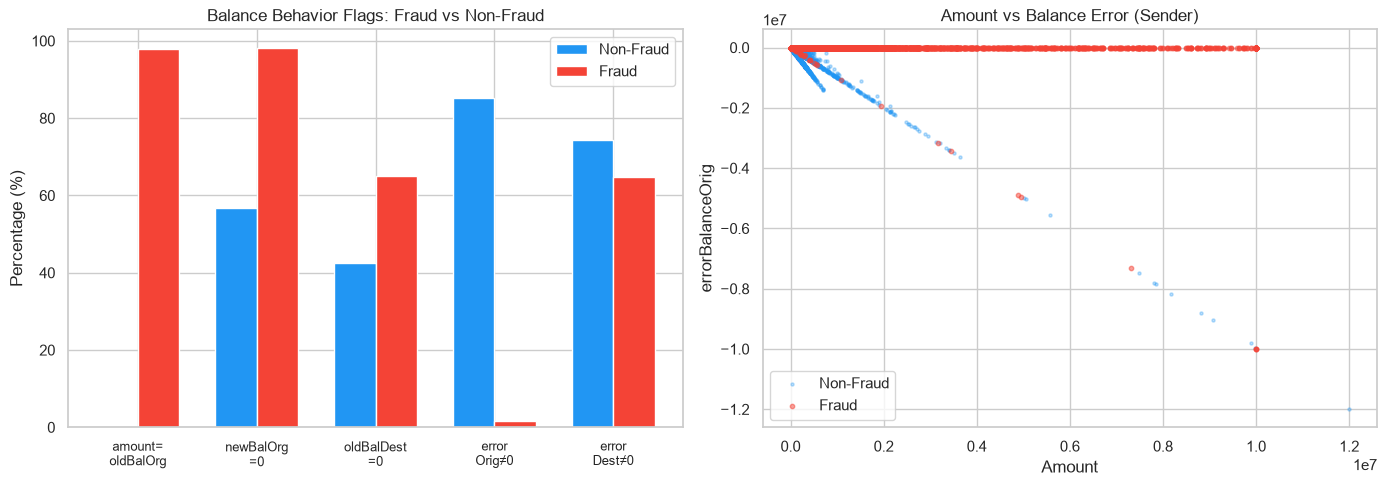

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar chart so sánh các flags
x = np.arange(len(result_df))
width = 0.35
axes[0].bar(x - width/2, result_df['Non-Fraud (%)'], width, label='Non-Fraud', color='#2196F3')
axes[0].bar(x + width/2, result_df['Fraud (%)'], width, label='Fraud', color='#F44336')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['amount=\noldBalOrg', 'newBalOrg\n=0', 'oldBalDest\n=0', 
                          'error\nOrig≠0', 'error\nDest≠0'], fontsize=9)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Balance Behavior Flags: Fraud vs Non-Fraud')
axes[0].legend()
# Scatter: errorBalanceOrig distribution
sample_fraud = df[df['isFraud'] == 1].sample(min(5000, df['isFraud'].sum()), random_state=42)
sample_non_fraud = df[df['isFraud'] == 0].sample(5000, random_state=42)
axes[1].scatter(sample_non_fraud['amount'], sample_non_fraud['errorBalanceOrig'], 
                alpha=0.3, s=5, color='#2196F3', label='Non-Fraud')
axes[1].scatter(sample_fraud['amount'], sample_fraud['errorBalanceOrig'], 
                alpha=0.5, s=10, color='#F44336', label='Fraud')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('errorBalanceOrig')
axes[1].set_title('Amount vs Balance Error (Sender)')
axes[1].legend()
plt.tight_layout()
plt.show()

errorBalanceOrig=oldbalanceOrg−amount−newbalanceOrig
errorBalanceDest=oldbalanceDest+amount−newbalanceDest

Fraud:
- Thường amount = oldbalanceOrg
- Thường newbalanceOrig = 0
- Thường errorBalanceOrig = 0

Non-Fraud:
- Ít khi amount = oldbalanceOrg
- Có nhiều trường hợp newbalanceOrig = 0
- Có nhiều lỗi errorBalanceOrig ≠ 0

=> Nhiều giao dịch fraud giống hành vi “rút sạch tiền khỏi tài khoản gửi”.

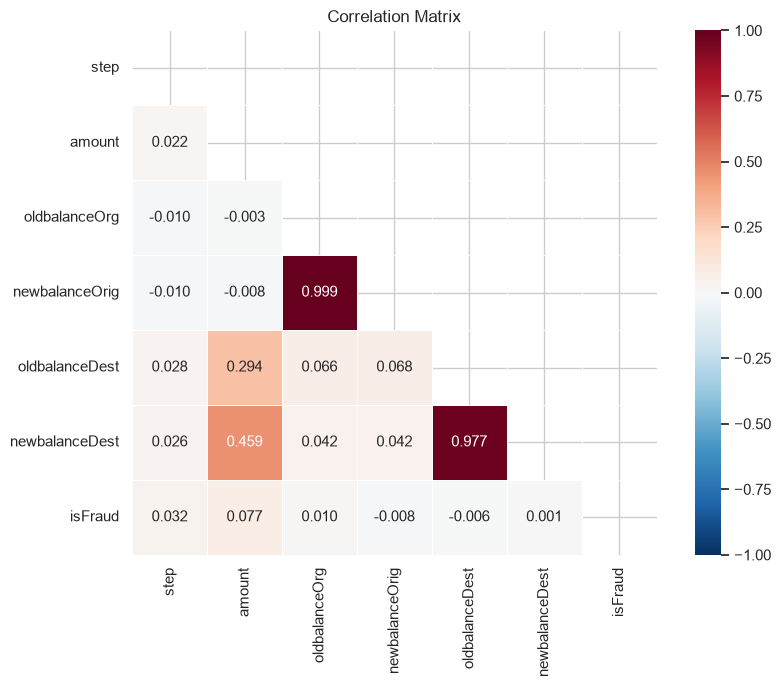

=== Correlation with isFraud ===
isFraud           1.000000
amount            0.076688
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148


In [13]:
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                'oldbalanceDest', 'newbalanceDest', 'isFraud']
corr = df[numeric_cols].corr()
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', fmt='.3f',
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
# Correlation with isFraud
print("=== Correlation with isFraud ===")
print(corr['isFraud'].sort_values(ascending=False).to_string())